In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from langgraph.checkpoint.postgres import PostgresSaver

from typing import Annotated, List, TypedDict

from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_groq import ChatGroq

from dotenv import load_dotenv
import os

c:\Users\Ansh\OneDrive\Desktop\Langraph\meraenv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
c:\Users\Ansh\OneDrive\Desktop\Langraph\meraenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()  # load the dotenv file..


True

In [3]:
llm = ChatGroq(
    model = 'llama-3.1-8b-instant',
    groq_api_key = os.getenv('GROQ_API_KEY'),
    temperature=0.2
)

In [4]:
llm.invoke('what is apple').content

'"Apple" can refer to several things, but I\'ll cover the most common meanings:\n\n1. **Apple (Fruit)**: Apple is a type of juicy, sweet fruit that grows on apple trees (Malus domestica). It\'s a popular fruit worldwide, often eaten fresh, used in cooking, or made into products like juice, cider, and vinegar.\n2. **Apple Inc.**: Apple Inc. is an American multinational technology company founded on April 1, 1976, by Steve Jobs, Steve Wozniak, and Ronald Wayne. The company is known for designing, manufacturing, and marketing consumer electronics, computer software, and online services. Some of Apple\'s most famous products include:\n\t* iPhones (smartphones)\n\t* Mac computers (laptops and desktops)\n\t* iPads (tablets)\n\t* Apple Watches (wearable devices)\n\t* AirPods (wireless earbuds)\n\t* Apple TV (streaming media player)\n\t* iCloud (cloud storage and services)\n\t* iTunes (digital media player and store)\n3. **Apple (Symbolism)**: In various cultures, apples have symbolic meanings

In [5]:
#LOAD THE PDF FILE..

from langchain_community.document_loaders import PyMuPDFLoader
loader = PyMuPDFLoader('Langchain and LangGraph Interview QA.pdf')
docs = loader.load()  # this funciton loads the document in form of list..


C:\Users\Ansh\AppData\Local\Temp\ipykernel_17208\4272046731.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


In [6]:
docs   # list of all pages and each page is a document object.

[Document(metadata={'producer': 'pdfTeX-1.40.26', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-24T16:16:19+00:00', 'source': 'Langchain and LangGraph Interview QA.pdf', 'file_path': 'Langchain and LangGraph Interview QA.pdf', 'total_pages': 49, 'format': 'PDF 1.7', 'title': 'Top 100 LangChain and LangGraph Interview Q&A', 'author': 'Lamhot Siagian', 'subject': '', 'keywords': '', 'moddate': '2026-03-24T16:16:19+00:00', 'trapped': '', 'modDate': 'D:20260324161619Z', 'creationDate': 'D:20260324161619Z', 'page': 0}, page_content='Top 100\nLangChain & LangGraph\nInterview Q&A\nClassified by Categories\nA categorized handbook covering foundations, agents, tools, RAG,\nmemory, stateful orchestration, persistence, evaluation,\ndeployment, and production design.\nLamhot Siagian\nAI Engineering Insider'),
 Document(metadata={'producer': 'pdfTeX-1.40.26', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-24T16:16:19+00:00', 'source': 'Langchain and LangGraph Interview QA.p

In [7]:
docs[48]

# if there are 49 pages then 49 document objects are created

# the content is present inside page_content

Document(metadata={'producer': 'pdfTeX-1.40.26', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-24T16:16:19+00:00', 'source': 'Langchain and LangGraph Interview QA.pdf', 'file_path': 'Langchain and LangGraph Interview QA.pdf', 'total_pages': 49, 'format': 'PDF 1.7', 'title': 'Top 100 LangChain and LangGraph Interview Q&A', 'author': 'Lamhot Siagian', 'subject': '', 'keywords': '', 'moddate': '2026-03-24T16:16:19+00:00', 'trapped': '', 'modDate': 'D:20260324161619Z', 'creationDate': 'D:20260324161619Z', 'page': 48}, page_content='About the Author\nLamhot Siagian is the founder of AI Engineering Insider. His work focuses on AI\nengineering, LLM systems, evaluation, automation, and practical interview preparation for\nengineers building real-world AI products.\nAI Engineering Insider\n43\nLamhot Siagian')

In [8]:
docs[6].page_content

'Chapter 1\nFoundations and Ecosystem\nCategory Focus\nWhat LangChain and LangGraph are, where they fit, and how to explain the stack\nclearly in interviews.\nWhy this category matters: These questions show up because this category affects\nhow reliable, explainable, and production-ready your system design sounds during\ninterviews.\nQ1. What is LangChain?\nAnswer. LangChain is an application framework for building LLM-powered systems\nwith reusable building blocks such as models, messages, tools, agents, memory, mid-\ndleware, and streaming. In current LangChain v1, the center of gravity is agent devel-\nopment: you can start with a high-level agent API, plug in any supported model and\ntools, and then add production features like structured output, tracing, and guardrails.\nIn an interview, describe LangChain as the orchestration layer that standardizes how\nyour app talks to models and surrounding systems.\nInterview angle. A strong answer connects LangChain to business outcomes: fa

In [9]:
# define the embedding model that converts sentences into embeddings..
from langchain_huggingface import HuggingFaceEmbeddings

embed = HuggingFaceEmbeddings(
    model_name = 'BAAI/bge-small-en-v1.5'
)


In [10]:
from langchain_experimental.text_splitter import SemanticChunker

chunker = SemanticChunker(
    embeddings = embed,
    breakpoint_threshold_type = 'percentile',
    breakpoint_threshold_amount = 95
)



C:\Users\Ansh\AppData\Local\Temp\ipykernel_17208\2155581211.py:1: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.text_splitter import SemanticChunker


In [12]:
chunks = chunker.split_documents(docs)  # give the docs object.

KeyboardInterrupt: 

In [13]:
len(chunks)   # 198 chunks are made from 49 pages

198

In [14]:
chunks[0].page_content

'Top 100\nLangChain & LangGraph\nInterview Q&A\nClassified by Categories\nA categorized handbook covering foundations, agents, tools, RAG,\nmemory, stateful orchestration, persistence, evaluation,\ndeployment, and production design. Lamhot Siagian\nAI Engineering Insider'

In [15]:
# initialze the vector database..
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore

vectordb = Pinecone(
    api_key=os.getenv("PINECONE_API_KEY")
)
index = vectordb.Index("ansh")


In [43]:
storage = PineconeVectorStore.from_documents(chunks,embed,index_name = 'ansh')

In [17]:
query = 'what is the difference between langgraph and langchain explain me in depth'

In [44]:
results = storage.similarity_search(query, k = 3)

In [45]:
for i in results:
    print(i.page_content)
    print('*****')

1
Q3. How do LangChain and LangGraph relate to each other? .
*****
1
Q3. How do LangChain and LangGraph relate to each other? .
*****
CHAPTER 1. FOUNDATIONS AND ECOSYSTEM
Lamhot Siagian
made of state, nodes, and edges. Its key strengths are durable execution, persis-
tence, human-in-the-loop pauses, streaming, and precise routing. If LangChain gives
you a convenient prebuilt agent path, LangGraph gives you fine-grained control over
every transition and state update. It is especially useful when a workflow must branch,
loop, recover from failure, or pause for approvals. Interview angle. Interviewers like hearing that LangGraph is for control and relia-
bility, not just for complexity’s sake. Q3. How do LangChain and LangGraph relate to each other? Answer. They are complementary, not competing. LangChain gives you higher-level
abstractions for building agents quickly, while LangGraph provides the runtime and
orchestration patterns for more explicit control. The current docs explicitly po

In [46]:
retriever = storage.as_retriever(search_type = 'similarity', search_kwargs = {'k':4})


In [47]:
# These are the thresholds values.
upper = 0.7
lower = 0.3

**LANGGRAPH**

In [73]:
from langchain_core.documents import Document
from typing import Literal

class Crag(TypedDict):
    question: str
    docs: List[Document]
    good_docs: List[Document]
    web_docs:List[Document]
    final_answer: str
    strips: str
    kept_strips: List[str]
    refined_context: str
    score: float
    reason: str
    verdict: Literal['Correct','Incorrect','Ambigous']


In [49]:
def retrieve(state: Crag):
    docs = retriever.invoke(state['question'])
    # for i in docs:
    #     print(i.page_content)
    #     print('**********')
    return {'docs':docs}


In [ ]:
from langchain_core.prompts import ChatPromptTemplate
import re
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# -----------------------------
# FILTER (LLM judge)
# -----------------------------

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question or false. \n"
            "Use ONLY the sentence. The output should be one word only True or False only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm


# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state):

    q = state["question"]

    # Combine retrieved docs into one context string
    if state['verdict']=='Correct':    # if good_docs present then use good else use web docs for refinement..
        context = "\n\n".join(d.page_content for d in state["good_docs"]).strip()
    else:
        context = "\n\n".join(d.page_content for d in state["web_docs"]).strip()

    

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []    # this is used as pydantic..
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).content=='True':
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }


In [ ]:
from pydantic import BaseModel
class Score(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(Score)

def score(state:Crag):
    q = state["question"]

    scores = []
    reasons = []
    good = []
    
    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        # 5) for CORRECT case we will refine only docs with score > LOWER_TH
        if out.score > lower:
            good.append(d)
        

        for s in scores:
            if s>lower:
                return {'verdict':'Correct','good_docs':good}
            elif s<lower:
                return {'verdict':'Incorrect','good_docs':good}
            else:
                return {'verdict':'Ambiguos', 'good_docs':good}





In [52]:
def generate_answer(state):
    prompt = f"Now you have the context{state['refined_context']} and user query{state['question']} so now frame a neat and clean answer"
    final_answer = llm.invoke(prompt).content
    return{'final_answer':final_answer}

In [53]:
def web_search(state):
    pass

In [54]:
def ambigous(state):
    pass

In [55]:
def evalu(state):
    if state['verdict']=='Correct':
        return 'refine'
    elif state['verdict']=='Incorrect':
        return 'web_search'
    else:
        return 'ambigous'

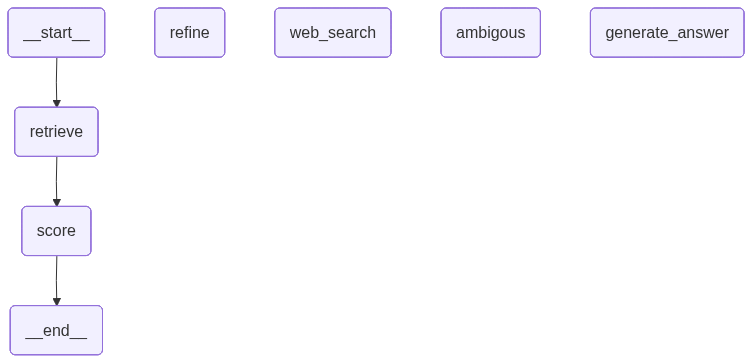

In [ ]:
graph = StateGraph(Crag)

graph.add_node('retrieve', retrieve)
graph.add_node('score',score)
graph.add_node('refine',refine)
graph.add_node('web_search',web_search)
graph.add_node('ambigous',ambigous)
#graph.add_node('evalu',evalu)
graph.add_node('generate_answer',generate_answer)

graph.add_edge(START, 'retrieve')
graph.add_edge('retrieve','score')
graph.add_conditional_edges('score',evalu)
graph.add_edge('web_search','refine')
graph.add_egde('ambigous','refine')
graph.add_edge('refine','generate_answer')
graph.add_edge('generate_answer',END)

workflow = graph.compile()

workflow


In [63]:
final = workflow.invoke({'question':'What is the difference between Langchain and langgraph'})
final['final_answer']

"**Langchain vs Langgraph: A Comparison**\n\nLangchain and Langgraph are two popular tools used in the field of natural language processing (NLP) and artificial intelligence (AI). While both tools are designed to facilitate human-AI collaboration and enhance language understanding, they have distinct differences in their approach, functionality, and use cases.\n\n**Langchain**\n\nLangchain is an open-source platform that enables developers to build human-AI collaboration systems. It provides a set of tools and APIs for creating conversational interfaces, integrating with external services, and processing natural language inputs. Langchain's primary focus is on enabling developers to build custom AI-powered applications that can understand and respond to human language.\n\n**Langgraph**\n\nLanggraph, on the other hand, is a graph-based language model that uses a novel approach to represent and process language. It represents language as a graph, where nodes represent words or concepts, 

In [116]:
final['strips']

['How do LangChain and LangGraph relate to each other?',
 'FOUNDATIONS AND ECOSYSTEM Lamhot Siagian made of state, nodes, and edges.',
 'Its key strengths are durable execution, persis- tence, human-in-the-loop pauses, streaming, and precise routing.',
 'If LangChain gives you a convenient prebuilt agent path, LangGraph gives you fine-grained control over every transition and state update.',
 'It is especially useful when a workflow must branch, loop, recover from failure, or pause for approvals.',
 'Interviewers like hearing that LangGraph is for control and relia- bility, not just for complexity’s sake.',
 'How do LangChain and LangGraph relate to each other?',
 'They are complementary, not competing.',
 'LangChain gives you higher-level abstractions for building agents quickly, while LangGraph provides the runtime and orchestration patterns for more explicit control.',
 'The current docs explicitly position LangChain agents as being built on LangGraph.',
 'That means you can start w

In [117]:
final['kept_strips']

['If LangChain gives you a convenient prebuilt agent path, LangGraph gives you fine-grained control over every transition and state update.',
 'LangChain gives you higher-level abstractions for building agents quickly, while LangGraph provides the runtime and orchestration patterns for more explicit control.',
 'The current docs explicitly position LangChain agents as being built on LangGraph.']

In [68]:
for i in final['good_docs']:
    print(i.page_content)

1
Q3. How do LangChain and LangGraph relate to each other? .


In [15]:
import sys
!{sys.executable} -m pip install pinecone langchain-pinecone

     ---------------------------------------- 0.0/71.9 kB ? eta -:--:--
     ---------------------------------------- 0.0/71.9 kB ? eta -:--:--
     ---------------------------------- ----- 61.4/71.9 kB 1.6 MB/s eta 0:00:01
     -------------------------------------- 71.9/71.9 kB 979.0 kB/s eta 0:00:00
   ---------------------------------------- 0.0/587.6 kB ? eta -:--:--
   ----------------- ---------------------- 256.0/587.6 kB 5.2 MB/s eta 0:00:01
   ---------------------------------- ----- 512.0/587.6 kB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 587.6/587.6 kB 4.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/259.3 kB ? eta -:--:--
   ---------------------------------------  256.0/259.3 kB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 259.3/259.3 kB 3.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/87.2 kB ? eta -:--:--
   ---------------------------------------- 87.2/87.2 kB 2.5 MB/s eta 0:00:00
   ---


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import sys
!{sys.executable} -m pip install langchain_experimental

  Using cached langchain_experimental-0.4.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached langchain_core-1.4.7-py3-none-any.whl.metadata (4.5 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached langchain_protocol-0.0.17-py3-none-any.whl.metadata (2.4 kB)
  Using cached langchain_text_splitters-1.1.2-py3-none-any.whl.metadata (3.3 kB)
Using cached langchain_experimental-0.4.2-py3-none-any.whl (211 kB)
Using cached langchain_community-0.4.2-py3-none-any.whl (2.4 MB)
Using cached langchain_core-1.4.7-py3-none-any.whl (554 kB)
Using cached langchain_classic-1.0.8-py3-none-any.whl (1.0 MB)
Using cached langchain_protocol-0.0.17-py3-none-any.whl (7.1 kB)
Using cached langchain_text_splitters-1.1.2-py3-none-any.whl (35 kB)
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.5
    Uninstalling langchain-core-1.2.5:
      Successfully un


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import sys
!{sys.executable} -m pip install langchain-huggingface sentence-transformers



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import sys
!{sys.executable} -m pip install pymupdf


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
import sys
!{sys.executable} -m pip install --force-reinstall langchain-core

  Using cached langchain_core-1.4.7-py3-none-any.whl.metadata (4.5 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_protocol-0.0.17-py3-none-any.whl.metadata (2.4 kB)
  Using cached langsmith-0.8.15-py3-none-any.whl.metadata (17 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached uuid_utils-0.16.0-cp311-cp311-win_amd64.whl.metadata (6.5 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached orjson-3.11.9-cp311-cp311-win_amd64.whl.metadata (43 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached req

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.56.0 requires websockets<15.1.0,>=13.0.0, but you have websockets 16.0 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
